# 🏠 Tunisia Real Estate — Full Data Pipeline
### Cleaning · Feature Engineering · LLM Extraction · Geocoding

**Dataset**: `final_dataset_all_sources_endpoint.csv` — 207K rows, 46 columns, sources: monbien.tn / menzili / tunisiapromo / mubaweb  
**Languages in description**: French · Arabic · Tunisian dialect  
**Goal**: Clean, enrich, and extract features ready for a price-prediction ML model

---
**Pipeline overview:**
```
Raw CSV
  ├── Section 1: Setup & Load
  ├── Section 2: EDA
  ├── Section 3: Cleaning (type, price, surface, rooms, dates, booleans, dedup)
  ├── Section 4: Rule-based Extraction from description/caracteristiques (regex)
  ├── Section 5: LLM Extraction (local transformers NER + Groq free API)
  ├── Section 6: Geocoding → lat/lng (Nominatim / OpenStreetMap — free, no key)
  ├── Section 7: Proximity Score → bon_entourage
  ├── Section 8: Premium Feature → haut_standing
  └── Section 9: Export
```
**All tools used are 100% free (no paid API).**

---
## Section 1 — Setup

In [1]:
# Run once — install all required packages
%pip install pandas numpy matplotlib seaborn tqdm geopy transformers torch
%pip install groq requests unidecode



Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np
import re
import json
import time
import warnings
from pathlib import Path
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from unidecode import unidecode

warnings.filterwarnings('ignore')
tqdm.pandas()
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 120)
plt.style.use('seaborn-v0_8-whitegrid')

print("✅ Imports OK")

c:\Users\21650\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✅ Imports OK


In [3]:
# ─────────────────────────────────────────────────────────────────
# CONFIGURATION  — edit here
# ─────────────────────────────────────────────────────────────────

DATA_PATH = Path(r"final_dataset_all_sources_endpoint.csv")  # relative path works if notebook is in same folder

# Free Groq API key — sign up at https://console.groq.com (no credit card)
# Leave as None to skip the Groq LLM step and rely on regex + local transformers
GROQ_API_KEY = "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"  # e.g. "gsk_xxxxxxxxxxxx"

# How many rows to process with the LLM (can be slow; regex handles most cases)
LLM_SAMPLE_SIZE = 500   # set to None for full dataset (very slow without GPU)

# Geocoding: max rows to geocode (Nominatim = 1 req/sec, 3600/hour)
GEO_SAMPLE_SIZE = 2000  # set to None for full dataset

RANDOM_SEED = 42
OUTPUT_PATH = Path("tunisia_realestate_cleaned.csv")

print(f"Data: {DATA_PATH}")
print(f"LLM: {'Groq enabled' if GROQ_API_KEY else 'Regex + local transformers only'}")

Data: final_dataset_all_sources_endpoint.csv
LLM: Groq enabled


---
## Section 2 — Data Loading & EDA

In [4]:
df_raw = pd.read_csv(DATA_PATH, low_memory=False)
print(f"Shape: {df_raw.shape}")
print(f"Columns ({len(df_raw.columns)}): {df_raw.columns.tolist()}")
df_raw.head(3)

Shape: (207374, 46)
Columns (46): ['adresse', 'annee_constr', 'bus', 'caracteristiques', 'code_postal', 'contrat', 'date_publication', 'date_scraping', 'description', 'ecole', 'ecole_nearest', 'etage', 'gouvernerat', 'has_ascenseur', 'has_balcon', 'has_chaffage', 'has_climatisation', 'has_garage', 'has_gardien', 'has_jardin', 'has_parking', 'has_piscine', 'has_terrasse', 'hopital', 'hopital_nearest', 'images', 'latitude', 'longitude', 'magasin', 'magasin_nearest', 'marche', 'marche_nearest', 'pharmacie', 'pharmacie_nearest', 'pieces', 'prix', 'railway', 'restaurant', 'restaurant_nearest', 'source', 'standing', 'surface', 'titre', 'type', 'url', 'ville']


,adresse,annee_constr,bus,caracteristiques,code_postal,contrat,date_publication,date_scraping,description,ecole,ecole_nearest,etage,gouvernerat,has_ascenseur,has_balcon,has_chaffage,has_climatisation,has_garage,has_gardien,has_jardin,has_parking,has_piscine,has_terrasse,hopital,hopital_nearest,images,latitude,longitude,magasin,magasin_nearest,marche,marche_nearest,pharmacie,pharmacie_nearest,pieces,prix,railway,restaurant,restaurant_nearest,source,standing,surface,titre,type,url,ville
0,NaN,NaN,NaN,NaN,NaN,vente,NaN,NaN,Réf: AH079 Nabeul / Hammamet centre Appartement / à vendre il y a 3 jours 🏢#MS_IMMOBILIER🏢met en #vente🎉un #appartem...,NaN,NaN,NaN,NaN,NaN,NaN,1.0,1.0,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,https://www.monbien.tn/media/cache/resolve/photo_1000_708/uploads/photos/68890dc5-69a6-41a8-bbd1-3bac003c36c7.jpg | ...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,320000.0,NaN,NaN,NaN,legacy_ahmed,NaN,76.0,Appartement s+1 avec vue de mer à hammamet à vendre 51355351,appartement,https://www.monbien.tn/properties/7594/appartement-s-1-avec-vue-de-mer-a-hammamet-a-vendre-51355351,NaN
1,NaN,NaN,NaN,NaN,NaN,vente,NaN,NaN,Réf: AH001 Nabeul / Hammamet centre Appartement / à vendre il y a 3 jours 📝#Direct #promoteur🗝🚪 🏢#MS_IMMOBILIER🏢vous...,NaN,NaN,NaN,NaN,1.0,NaN,1.0,1.0,1.0,NaN,1.0,NaN,NaN,1.0,NaN,NaN,https://www.monbien.tn/media/cache/resolve/photo_1000_708/uploads/photos/fd6dd91c-e294-4eb2-a719-0adf5c681124.jpg | ...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.0,385000.0,NaN,NaN,NaN,legacy_ahmed,NaN,109.0,Des appartements s+2 tout neuf à vendre à hammamet 51355351,appartement,https://www.monbien.tn/properties/7593/des-appartements-s-2-tout-neuf-a-vendre-a-hammamet-51355351,NaN
2,NaN,NaN,NaN,NaN,NaN,vente,NaN,NaN,Réf: AH077 Nabeul / Hammamet Appartement / à vendre il y a 3 jours 🙋🙋#ستوديو #للبيع🍡💥في #الحمامات بـ140 مليون# 🤑🤑 ☀️...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,https://www.monbien.tn/media/cache/resolve/photo_1000_708/uploads/photos/c0c732b1-cf05-49d0-8fbe-1c155e26c048.jpg | ...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,140000.0,NaN,NaN,NaN,legacy_ahmed,NaN,NaN,Coquet studio à vendre à 140 md à hammamet 51355351,appartement,https://www.monbien.tn/properties/7592/coquet-studio-a-vendre-a-140-md-a-hammamet-51355351,NaN


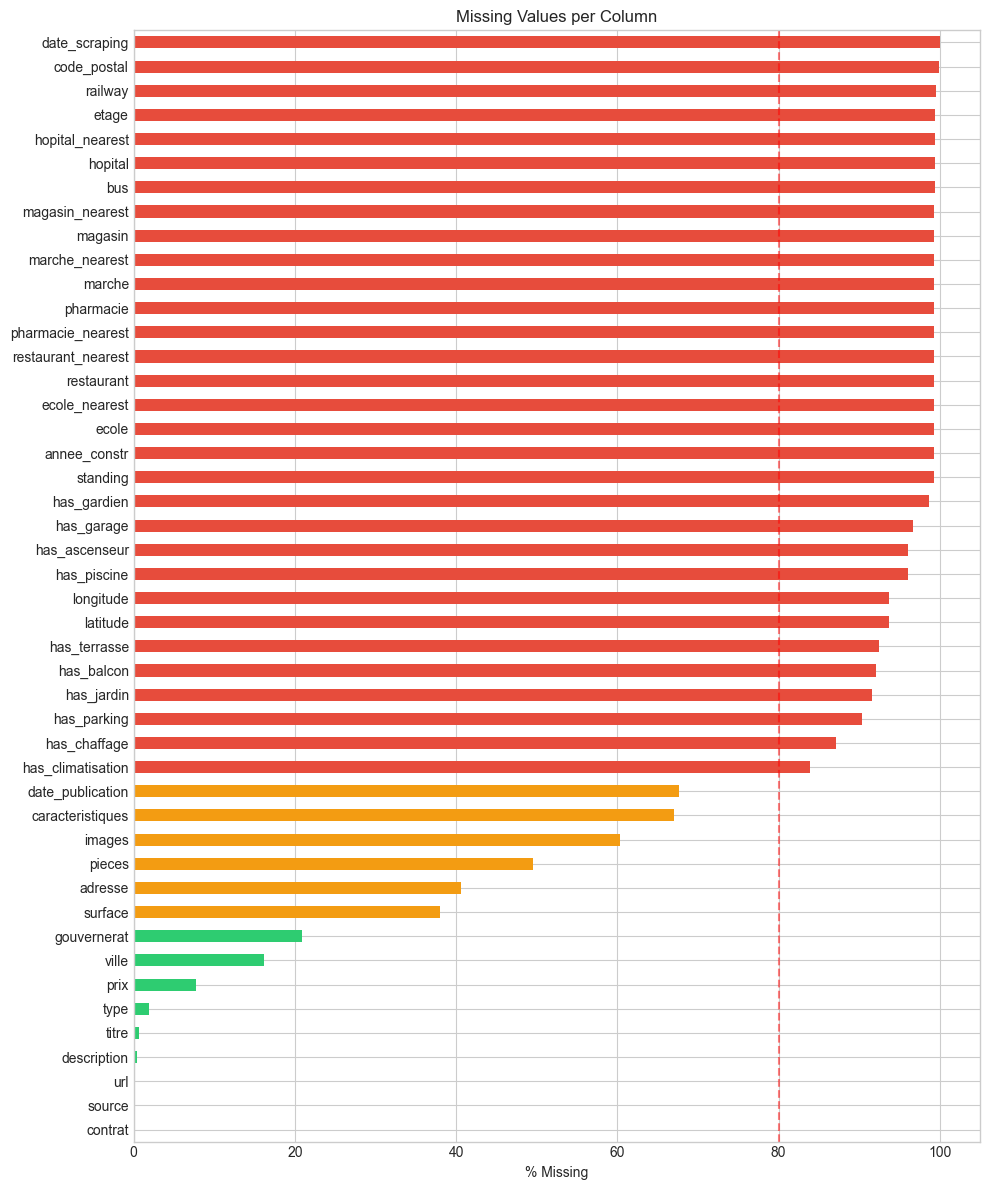


Columns > 80% missing (candidates for drop): ['has_climatisation', 'has_chaffage', 'has_parking', 'has_jardin', 'has_balcon', 'has_terrasse', 'latitude', 'longitude', 'has_piscine', 'has_ascenseur', 'has_garage', 'has_gardien', 'standing', 'annee_constr', 'ecole', 'ecole_nearest', 'restaurant', 'restaurant_nearest', 'pharmacie_nearest', 'pharmacie', 'marche', 'marche_nearest', 'magasin', 'magasin_nearest', 'bus', 'hopital', 'hopital_nearest', 'etage', 'railway', 'code_postal', 'date_scraping']

Columns with data (< 50% missing): ['contrat', 'source', 'url', 'description', 'titre', 'type', 'prix', 'ville', 'gouvernerat', 'surface', 'adresse', 'pieces']


In [5]:
# Null analysis
null_pct = (df_raw.isnull().mean() * 100).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 12))
null_pct.plot(kind='barh', ax=ax, color=null_pct.map(lambda x: '#e74c3c' if x > 80 else '#f39c12' if x > 30 else '#2ecc71'))
ax.set_xlabel('% Missing')
ax.set_title('Missing Values per Column')
ax.axvline(x=80, color='red', linestyle='--', alpha=0.5, label='80% threshold')
plt.tight_layout()
plt.savefig('missing_values.png', dpi=100)
plt.show()

print("\nColumns > 80% missing (candidates for drop):", null_pct[null_pct > 80].index.tolist())
print("\nColumns with data (< 50% missing):", null_pct[null_pct < 50].index.tolist())

In [6]:
# Key column distributions
print("=== CONTRAT ===")
print(df_raw['contrat'].value_counts())

print("\n=== TYPE (top 15) ===")
print(df_raw['type'].value_counts().head(15))

print("\n=== GOUVERNERAT (top 15) ===")
print(df_raw['gouvernerat'].value_counts().head(15))

print("\n=== SOURCE ===")
print(df_raw['source'].value_counts())

print("\n=== PRIX (before cleaning) ===")
print(df_raw['prix'].describe())

print("\n=== SURFACE (before cleaning) ===")
print(df_raw['surface'].describe())

=== CONTRAT ===
contrat
location             106536
vente                100507
location_vacances       169
colocation              110
autre                    52
Name: count, dtype: int64

=== TYPE (top 15) ===
type
appartement                   51808
Appartement                   32120
Villa                         29280
maison                        25018
Maison                        23896
Terrain                       22209
terrain                        4029
Local commercial               2543
S2                             2082
Studio                         1948
S3                             1738
Duplex                         1599
Bureau                         1254
S1                              694
Annonce Tunisie Immobilier      681
Name: count, dtype: int64

=== GOUVERNERAT (top 15) ===
gouvernerat
Nabeul       77667
tunis        44823
Tunis        13501
Ariana        6071
Sousse        4801
nabeul        2760
sousse        2390
ariana        1916
ben arous     1428
Biz

In [7]:
# Show a few raw descriptions
print("--- Sample description (row 0) ---")
print(df_raw['description'].dropna().iloc[0][:800])
print("\n--- Sample description (row 10, checking Arabic) ---")
for desc in df_raw['description'].dropna():
    if any('\u0600' <= c <= '\u06ff' for c in str(desc)):  # Arabic Unicode range
        print(desc[:600])
        break

--- Sample description (row 0) ---
Réf: AH079 Nabeul / Hammamet centre Appartement / à vendre il y a 3 jours 🏢#MS_IMMOBILIER🏢met en #vente🎉un #appartement richement #meublé de type🔑S+1 avec une grande #terrasse aménagée🚶🚶 ayant une #vue_sublime sur la #mer🏝🏖 mis au 2ème étage d'une petite #résidence #conviviale à #Hammamet_centre-ville ⛱️🌊 🎉Une terrasse #vue de #mer est disponible🏡 🌊🔌 Chauffage central préinstallé 📜 Documents: Titre foncier individuel encours 📐Superficie: 76 m² 💰 Prix: 320 MD 👋 Réf : AH079 👉Pour plus d’informations contactez-nous sur ☎51355351
Caracteristiques: Appartement s+1 avec vue de mer à hammamet à vendre 51355351 | Appartement | à vendre | 76.00 m | Chauffage centrale | Parabole / TV | Système Alarme | Climatisation | Terrasses | Meublé | Vue mer | Internet/Wi-fi | Hammamet , Nabeul Hammamet, 8050 |

--- Sample description (row 10, checking Arabic) ---
Réf: AH077 Nabeul / Hammamet Appartement / à vendre il y a 3 jours 🙋🙋#ستوديو #للبيع🍡💥في #الحمامات بـ140 مليون#

---
## Section 3 — Cleaning Pipeline

**Principle**: flag outliers → try to rescue from description → NaN only if unrescuable.  
We never delete rows here, only clean values.

In [8]:
df = df_raw.copy()
cleaning_log = []  # track every cleaning action

def log(msg, n=None):
    entry = f"[CLEAN] {msg}" + (f" → {n:,} rows affected" if n is not None else "")
    cleaning_log.append(entry)
    print(entry)

In [9]:
# ── 3.1 Property type normalization ────────────────────────────────
TYPE_MAP = {
    'appartement': 'Appartement', 'Appartement': 'Appartement',
    'maison': 'Maison', 'Maison': 'Maison',
    'terrain': 'Terrain', 'Terrain': 'Terrain',
    'Villa': 'Villa',
    'Studio': 'Studio',
    'Duplex': 'Duplex',
    'Bureau': 'Bureau',
    'Local commercial': 'Local Commercial',
    'Local Industriel': 'Local Industriel',
    'Immeuble': 'Immeuble',
    'Ferme': 'Ferme',
    'Garage': 'Garage',
    'Bungalow': 'Bungalow',
    'Hôtel Particulier': 'Hôtel Particulier',
    'Fond De Commerce': 'Fond De Commerce',
    'Place De Parc': 'Garage',  # treat as garage
    'Annonce Tunisie Immobilier': np.nan,  # useless
}
before = df['type'].isna().sum()
df['type'] = df['type'].map(lambda x: TYPE_MAP.get(str(x), x) if pd.notna(x) else x)
df.loc[df['type'] == 'nan', 'type'] = np.nan
after = df['type'].isna().sum()
log("type normalization", after - before)
print(df['type'].value_counts())

[CLEAN] type normalization → 681 rows affected
type
Appartement              83928
Maison                   48914
Villa                    29280
Terrain                  26238
Local Commercial          2543
S2                        2082
Studio                    1948
S3                        1738
Duplex                    1599
Bureau                    1254
S1                         694
Fond De Commerce           566
Ferme                      428
S4                         401
Immeuble                   281
Local Industriel           263
Garage                     182
Bungalow                   134
Appartement Meublé          76
S+                          71
Résidence                   42
Hôtel Particulier           35
Lot de Terrain              35
Terrain Vue Mer             28
Terrain Constructible       24
Terrain Agricole            18
Chambre Foyer               18
Terrain Commercial          16
Terrain Résidentiel         10
Triplex                      8
Penthouse         

In [10]:
# ── 3.2 Contrat normalization ──────────────────────────────────────
CONTRAT_MAP = {
    'vente': 'vente',
    'location': 'location',
    'colocation': 'colocation',
    'location_vacances': 'location_vacances',
    'autre': 'autre',
}
df['contrat'] = df['contrat'].str.strip().str.lower().map(CONTRAT_MAP).fillna('autre')
log("contrat normalization")
print(df['contrat'].value_counts())

[CLEAN] contrat normalization
contrat
location             106536
vente                100507
location_vacances       169
colocation              110
autre                    52
Name: count, dtype: int64


In [11]:
# ── 3.3 Gouvernerat & Ville normalization ──────────────────────────
GOUVERNERAT_CORRECT = {
    'ariana': 'Ariana', 'sousse': 'Sousse', 'nabeul': 'Nabeul',
    'manouba': 'Manouba', 'tunis': 'Tunis', 'ben arous': 'Ben Arous',
    'bizerte': 'Bizerte', 'gabes': 'Gabès', 'mahdia': 'Mahdia',
    'sfax': 'Sfax', 'beja': 'Béja', 'monastir': 'Monastir',
    'le kef': 'Le Kef', 'jendouba': 'Jendouba', 'kairouan': 'Kairouan',
    'kebili': 'Kébili', 'medenine': 'Médenine', 'siliana': 'Siliana',
    'gafsa': 'Gafsa', 'kasserine': 'Kasserine', 'zaghouan': 'Zaghouan',
    'tozeur': 'Tozeur', 'sidi bouzid': 'Sidi Bouzid', 'tataouine': 'Tataouine',
}
df['gouvernerat'] = (df['gouvernerat']
    .str.strip().str.lower()
    .map(lambda x: GOUVERNERAT_CORRECT.get(x, x.title() if pd.notna(x) else x))
)
df['ville'] = df['ville'].str.strip().str.title()
df['adresse'] = df['adresse'].str.strip()

log("gouvernerat/ville normalization")
print(df['gouvernerat'].value_counts().head(10))

[CLEAN] gouvernerat/ville normalization
gouvernerat
Nabeul       80427
Tunis        58324
Ariana        7987
Sousse        7191
Ben Arous     2632
Bizerte       1687
Sfax          1323
Mahdia        1041
Monastir      1025
Médenine       835
Name: count, dtype: int64


  [vente               ]  8,820 outliers → NaN  (bounds:     10,000 –   10,000,000 TND)
  [location            ]    726 outliers → NaN  (bounds:        100 –       50,000 TND)
  [location_vacances   ]      4 outliers → NaN  (bounds:         50 –        5,000 TND)
  [colocation          ]     13 outliers → NaN  (bounds:        100 –        5,000 TND)
  [autre               ]      0 outliers → NaN  (bounds:        100 –   10,000,000 TND)
[CLEAN] prix: outliers zeroed → 9,563 rows affected


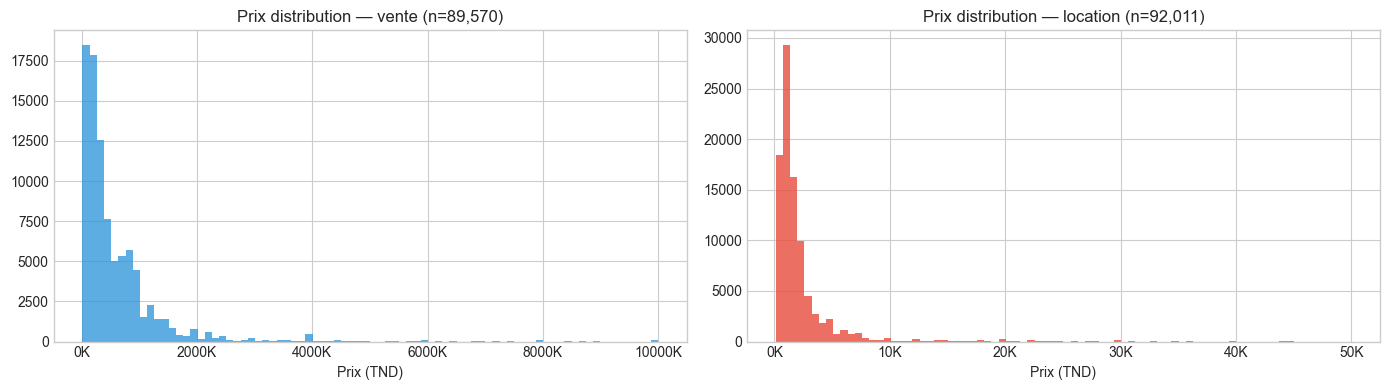

In [12]:
# ── 3.4 Price cleaning ──────────────────────────────────────────────
# Tunisian context:
#   - Prices in TND (Tunisian Dinar)
#   - "MD" in listings = mille dinars → multiply by 1000 only if value < 1000
#     BUT the dataset already seems to store prices in TND (320000 for 320 MD)
#   - Reasonable bounds:
#     vente: 10 000 – 10 000 000 TND
#     location: 100 – 50 000 TND/month
#     location_vacances: 50 – 5 000 TND/night-week
#     colocation: 100 – 5 000 TND/month

PRIX_BOUNDS = {
    'vente':             (10_000,   10_000_000),
    'location':          (100,       50_000),
    'location_vacances': (50,         5_000),
    'colocation':        (100,         5_000),
    'autre':             (100,      10_000_000),
}

df['prix_original'] = df['prix'].copy()  # keep original

total_outliers = 0
for contrat_type, (lo, hi) in PRIX_BOUNDS.items():
    mask = (df['contrat'] == contrat_type) & df['prix'].notna()
    outlier = mask & ((df['prix'] < lo) | (df['prix'] > hi))
    n = outlier.sum()
    df.loc[outlier, 'prix'] = np.nan
    total_outliers += n
    print(f"  [{contrat_type:20s}] {n:6,} outliers → NaN  (bounds: {lo:>10,} – {hi:>12,} TND)")

log(f"prix: outliers zeroed", total_outliers)

# Log distribution after cleaning
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, contrat_type, color in zip(axes, ['vente', 'location'], ['#3498db', '#e74c3c']):
    data = df.loc[df['contrat'] == contrat_type, 'prix'].dropna()
    ax.hist(data, bins=80, color=color, edgecolor='none', alpha=0.8)
    ax.set_title(f'Prix distribution — {contrat_type} (n={len(data):,})')
    ax.set_xlabel('Prix (TND)')
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e3:.0f}K'))
plt.tight_layout()
plt.savefig('prix_distribution.png', dpi=100)
plt.show()

In [13]:
# ── 3.5 Surface cleaning ────────────────────────────────────────────
# Reasonable range: 10 – 10 000 m² for most property types
# Terrains can be larger: up to 50 000 m²

df['surface_original'] = df['surface'].copy()

# Detect obvious garbage (e.g. 2.1e9, 0)
mask_terrain = df['type'] == 'Terrain'
surface_hi = np.where(mask_terrain, 50_000, 10_000)

outlier_surface = df['surface'].notna() & (
    (df['surface'] < 5) | (df['surface'] > pd.Series(surface_hi, index=df.index))
)
n = outlier_surface.sum()
df.loc[outlier_surface, 'surface'] = np.nan
log(f"surface: outliers (< 5 or > 10K/50K m²) → NaN", n)
print(df['surface'].describe())

[CLEAN] surface: outliers (< 5 or > 10K/50K m²) → NaN → 715 rows affected
count    127747.000000
mean        410.296985
std        1175.225709
min           5.000000
25%         100.000000
50%         180.000000
75%         350.000000
max       46724.000000
Name: surface, dtype: float64


In [14]:
# ── 3.6 Pieces (rooms) cleaning ────────────────────────────────────
df['pieces_original'] = df['pieces'].copy()

# Reasonable: 0 (studio) – 20 rooms
outlier_pieces = df['pieces'].notna() & ((df['pieces'] < 0) | (df['pieces'] > 20))
n = outlier_pieces.sum()
df.loc[outlier_pieces, 'pieces'] = np.nan
log("pieces: outliers (< 0 or > 20) → NaN", n)
print(df['pieces'].value_counts().sort_index().head(15))

[CLEAN] pieces: outliers (< 0 or > 20) → NaN → 98 rows affected
pieces
0.0       930
1.0      4895
2.0     20941
3.0     33889
4.0     22379
5.0     10845
6.0      5245
7.0      2410
8.0      1304
9.0       543
10.0      981
11.0       80
12.0      116
13.0       41
14.0       18
Name: count, dtype: int64


In [15]:
# ── 3.7 Etage (floor) cleaning ─────────────────────────────────────
# Reasonable: 0 (ground floor / RDC) – 30
df['etage_original'] = df['etage'].copy()
outlier_etage = df['etage'].notna() & ((df['etage'] < 0) | (df['etage'] > 30))
df.loc[outlier_etage, 'etage'] = np.nan
log("etage: outliers → NaN", outlier_etage.sum())

[CLEAN] etage: outliers → NaN → 3 rows affected


In [16]:
# ── 3.8 annee_constr cleaning ──────────────────────────────────────
# Reasonable: 1900 – current year
import datetime
current_year = datetime.datetime.now().year
outlier_yr = df['annee_constr'].notna() & ((df['annee_constr'] < 1900) | (df['annee_constr'] > current_year))
df.loc[outlier_yr, 'annee_constr'] = np.nan
log("annee_constr: out-of-range → NaN", outlier_yr.sum())

[CLEAN] annee_constr: out-of-range → NaN → 4 rows affected


In [17]:
# ── 3.9 Date parsing ───────────────────────────────────────────────
df['date_publication'] = pd.to_datetime(df['date_publication'], errors='coerce', dayfirst=True)

# Extract useful date features
df['pub_year']  = df['date_publication'].dt.year
df['pub_month'] = df['date_publication'].dt.month

log("date_publication → datetime")
print(f"Valid dates: {df['date_publication'].notna().sum():,}")
print(df['pub_year'].value_counts().sort_index())

[CLEAN] date_publication → datetime
Valid dates: 9,228
pub_year
2025.0    4419
2026.0    4809
Name: count, dtype: int64


In [18]:
# ── 3.10 Boolean columns (has_*) → int 0/1 ─────────────────────────
BOOL_COLS = [
    'has_ascenseur', 'has_balcon', 'has_chaffage', 'has_climatisation',
    'has_garage',  'has_gardien', 'has_jardin', 'has_parking',
    'has_piscine', 'has_terrasse',
    'bus', 'railway', 'ecole', 'hopital', 'pharmacie', 'magasin', 'marche', 'restaurant',
]
for col in BOOL_COLS:
    if col in df.columns:
        # Some sources store True/False/1.0/0.0/NaN
        df[col] = pd.to_numeric(df[col], errors='coerce').map(
            lambda x: 1 if x == 1.0 else (0 if x == 0.0 else np.nan)
        )

log("boolean columns normalized to 0/1/NaN")
print(df[BOOL_COLS].notna().sum().sort_values(ascending=False))

[CLEAN] boolean columns normalized to 0/1/NaN
has_climatisation    33303
has_chaffage         26580
has_parking          20028
has_jardin           17463
has_balcon           16306
has_terrasse         15624
has_piscine           8281
has_ascenseur         8137
has_garage            6744
has_gardien           2650
bus                      0
railway                  0
ecole                    0
hopital                  0
pharmacie                0
magasin                  0
marche                   0
restaurant               0
dtype: int64


In [19]:
# ── 3.11 Standing normalization ────────────────────────────────────
STANDING_MAP = {
    'haut standing': 'Haut Standing',
    'moyen standing': 'Moyen Standing',
    'populaire': 'Populaire',
    'ancien': 'Ancien',
}
df['standing'] = df['standing'].str.strip().str.lower().map(
    lambda x: STANDING_MAP.get(x, np.nan) if pd.notna(x) else np.nan
)
log("standing normalization")
print(df['standing'].value_counts())

[CLEAN] standing normalization
standing
Haut Standing     693
Moyen Standing    667
Ancien            151
Populaire          70
Name: count, dtype: int64


In [20]:
# ── 3.12 Deduplication ─────────────────────────────────────────────
n_before = len(df)

# Exact URL duplicates
df = df.drop_duplicates(subset='url', keep='first')
log("URL dedup", n_before - len(df))

# Near-duplicate: same titre + same prix + same surface (different sources)
n_before = len(df)
dup_cols = ['titre', 'prix', 'surface', 'gouvernerat']
dup_mask = df.duplicated(subset=dup_cols, keep='first') & df[dup_cols].notna().all(axis=1)
df = df[~dup_mask].reset_index(drop=True)
log("near-duplicate (titre+prix+surface+gouvernerat)", n_before - len(df))

print(f"Final shape after dedup: {df.shape}")

[CLEAN] URL dedup → 0 rows affected
[CLEAN] near-duplicate (titre+prix+surface+gouvernerat) → 2,629 rows affected
Final shape after dedup: (204745, 52)


In [21]:
# ── 3.13 Parse embedded 'Caracteristiques:' block from description ──
# Many descriptions contain a pipe-separated block like:
# "Caracteristiques: Appartement | à vendre | 76.00 m | Climatisation | Hammamet, 8050"
# This is extremely useful — we extract it into a separate column.

def split_description_carac(text):
    """Split description into (main_text, caracteristiques_block)."""
    if pd.isna(text):
        return np.nan, np.nan
    text = str(text)
    # Look for 'Caracteristiques:' separator (case-insensitive)
    m = re.search(r'[Cc]aracteristiques?\s*:', text)
    if m:
        return text[:m.start()].strip(), text[m.end():].strip()
    return text.strip(), np.nan

df[['desc_clean', 'carac_block']] = df['description'].apply(
    lambda x: pd.Series(split_description_carac(x))
)

print(f"desc_clean non-null: {df['desc_clean'].notna().sum():,}")
print(f"carac_block non-null: {df['carac_block'].notna().sum():,}")

# Parse carac_block pipe-separated fields
AMENITY_KEYWORDS_CARAC = {
    'piscine': 'has_piscine', 'jardin': 'has_jardin',
    'ascenseur': 'has_ascenseur', 'climatisation': 'has_climatisation',
    'terrasse': 'has_terrasse', 'garage': 'has_garage',
    'parking': 'has_parking', 'gardien': 'has_gardien',
    'balcon': 'has_balcon',
    'chauffage': 'has_chaffage', 'chaffage': 'has_chaffage',
}

def parse_carac_block(carac_str):
    """Parse pipe-separated caracteristiques block → dict of extracted values."""
    if pd.isna(carac_str):
        return {}
    parts = [p.strip() for p in str(carac_str).split('|')]
    result = {}

    for part in parts:
        part_lower = part.lower()

        # Surface: "76.00 m" or "76 m²"
        m = re.match(r'^(\d+\.?\d*)\s*(?:m²?|m2)\b', part_lower)
        if m and 'surface_carac' not in result:
            result['surface_carac'] = float(m.group(1))
            continue

        # Postal code: 4-digit Tunisian
        m = re.search(r'\b(\d{4})\b', part)
        if m and 'code_postal_carac' not in result:
            result['code_postal_carac'] = m.group(1)

        # Contrat hints
        if 'vendre' in part_lower or 'vente' in part_lower:
            result['contrat_carac'] = 'vente'
        elif 'louer' in part_lower or 'location' in part_lower:
            result['contrat_carac'] = 'location'

        # Amenities
        for kw, col in AMENITY_KEYWORDS_CARAC.items():
            if kw in part_lower:
                result[col] = 1

    return result

print("Parsing caracteristiques blocks...")
carac_dicts = df['carac_block'].progress_apply(parse_carac_block)
carac_df = pd.DataFrame(list(carac_dicts), index=df.index)

# Fill missing values in df from carac_df
for col in carac_df.columns:
    if col in df.columns:
        filled = df[col].isna() & carac_df[col].notna()
        df.loc[filled, col] = carac_df.loc[filled, col]
        log(f"  carac_block → {col}", filled.sum())
    else:
        df[col] = carac_df[col]

print("✅ Caracteristiques block parsed")

desc_clean non-null: 203,872
carac_block non-null: 2,472
Parsing caracteristiques blocks...


100%|██████████| 204745/204745 [00:00<00:00, 1008709.45it/s]


[CLEAN]   carac_block → has_chaffage → 0 rows affected
[CLEAN]   carac_block → has_climatisation → 2 rows affected
[CLEAN]   carac_block → has_terrasse → 2 rows affected
[CLEAN]   carac_block → has_garage → 1 rows affected
[CLEAN]   carac_block → has_jardin → 1 rows affected
[CLEAN]   carac_block → has_ascenseur → 0 rows affected
[CLEAN]   carac_block → has_piscine → 2 rows affected
[CLEAN]   carac_block → has_gardien → 0 rows affected
[CLEAN]   carac_block → has_parking → 0 rows affected
[CLEAN]   carac_block → has_balcon → 0 rows affected
✅ Caracteristiques block parsed


---
## Section 4 — Rule-based Feature Extraction (Regex)

Extract structured features from free-text **description** and **carac_block**.
Handles French, Arabic, and Tunisian dialect patterns.

We only overwrite a column if it is currently **NaN** (never overwrite existing values).

In [22]:
# ── Regex helper utilities ──────────────────────────────────────────

def normalize_number(s):
    """Turn '320 000' or '320.000' or '320,000' into 320000.0"""
    if s is None:
        return None
    s = str(s).strip()
    # Remove spaces used as thousand separators first, then handle decimal
    s = re.sub(r'\s', '', s)          # remove spaces: '320 000' → '320000'
    # If both . and , present: European format (1.234,56) → 1234.56
    if '.' in s and ',' in s:
        s = s.replace('.', '').replace(',', '.')
    elif ',' in s and re.search(r',\d{3}$', s):
        # comma as thousand sep: '320,000' → '320000'
        s = s.replace(',', '')
    elif '.' in s and re.search(r'\.\d{3}$', s):
        # dot as thousand sep: '320.000' → '320000'
        s = s.replace('.', '')
    else:
        s = s.replace(',', '.')
    try:
        return float(s)
    except ValueError:
        return None

def first_match(patterns, text, group=1, flags=re.IGNORECASE):
    """Return first regex group match from a list of patterns."""
    if pd.isna(text):
        return None
    for pat in patterns:
        m = re.search(pat, str(text), flags)
        if m:
            if group == 0:
                return m.group(0)
            return m.group(group) if m.lastindex and m.lastindex >= group else m.group(0)
    return None

# Quick test
assert normalize_number('320 000') == 320000.0
assert normalize_number('320.000') == 320000.0
assert normalize_number('1,200') == 1200.0
print("✅ Regex helpers OK")

✅ Regex helpers OK


In [23]:
# ── 4.1 Extract price from description ────────────────────────────
# Tunisian price conventions:
#   - "320 MD" or "320 MDT" = 320 × 1000 TND = 320,000 TND
#   - "320 000 TND", "320 000 DT"
#   - "💰 Prix: 320" (ambiguous — need context)
#   - "بـ140مليون" = 140 million millimes = 140,000 TND (rare)
#   - "ب 320 ألف" = 320,000 TND

PRICE_PATTERNS = [
    # "320 MD" / "320 MDT" / "320 000 MDT"
    (r'([\d][\d\s.,]*)\s*(?:MD[T]?|K\s*DT|mille\s*(?:dinar|TND|DT)s?)', 1000.0),
    # "320 000 TND", "320000 dinars"
    (r'([\d][\d\s.,]+)\s*(?:TND|DT|dinars?)\b', 1.0),
    # Arabic: "320 ألف دينار" = 320,000
    (r'([\d][\d\s.,]*)\s*(?:ألف\s*دينار|ألف\s*TND)', 1000.0),
    # Arabic: "320 مليون" = 320,000 TND (if unit = millimes × 1000)
    (r'([\d][\d\s.,]*)\s*مليون', 1000.0),
    # "Prix: 320 000" (no unit, assume TND if large enough)
    (r'(?:prix|price|💰)\s*[:\-]\s*([\d][\d\s.,]+)', 1.0),
    # "💰 320" (emoji followed by number — Tunisian habit)
    (r'💰\s*([\d][\d\s.,]+)', 1.0),
]

def extract_price(text):
    """Extract price in TND from description text."""
    if pd.isna(text):
        return np.nan
    text = str(text)
    for pattern, multiplier in PRICE_PATTERNS:
        m = re.search(pattern, text, re.IGNORECASE)
        if m:
            val = normalize_number(m.group(1))
            if val is not None and val > 0:
                price_tnd = val * multiplier
                # Sanity check: 50 TND to 20M TND
                if 50 <= price_tnd <= 20_000_000:
                    return price_tnd
    return np.nan

# Apply only where prix is NaN
needs_price = df['prix'].isna()
extracted_prices = df.loc[needs_price, 'description'].progress_apply(extract_price)
df.loc[needs_price, 'prix'] = extracted_prices
recovered = extracted_prices.notna().sum()
log(f"prix extracted from description", recovered)

print(f"\nAfter extraction — prix missing: {df['prix'].isna().sum():,} ({df['prix'].isna().mean()*100:.1f}%)")

100%|██████████| 25479/25479 [00:00<00:00, 46574.84it/s]

[CLEAN] prix extracted from description → 5,100 rows affected

After extraction — prix missing: 20,379 (10.0%)


In [24]:
# ── 4.2 Extract surface from description ──────────────────────────
SURFACE_PATTERNS = [
    r'([\d][\d\s.,]*)\s*(?:m²|m2|M²|M2)',
    r'(?:superficie|surface|superficie\s*totale|📐)\s*[:\-]?\s*([\d][\d\s.,]*)',
    r'([\d][\d\s.,]*)\s*(?:متر\s*مربع|م²|م2)',
    r'([\d][\d\s.,]*)\s*m\b(?!d)',  # "76 m" but not "MD"
    r'([\d]+\.\d+)\s*m\b',          # "76.00 m" from pipe format
]

def extract_surface(text):
    if pd.isna(text): return np.nan
    for pat in SURFACE_PATTERNS:
        m = re.search(pat, str(text), re.IGNORECASE)
        if m:
            val = normalize_number(m.group(1))
            if val and 5 <= val <= 50_000:
                return val
    return np.nan

needs_surface = df['surface'].isna()
extracted = df.loc[needs_surface, 'description'].progress_apply(extract_surface)
df.loc[needs_surface, 'surface'] = extracted
log("surface extracted from description", extracted.notna().sum())

print(f"surface missing after: {df['surface'].isna().sum():,} ({df['surface'].isna().mean()*100:.1f}%)")

100%|██████████| 79627/79627 [00:03<00:00, 22770.64it/s]

[CLEAN] surface extracted from description → 10,147 rows affected
surface missing after: 69,480 (33.9%)


In [25]:
# ── 4.3 Extract rooms (pièces) from description ────────────────────
# Tunisian notation: S+N → S=salon, N=bedrooms, total rooms = N+2 (salon+sdb)
# S+1 = 2 pieces total, S+2 = 3 pieces, S+3 = 4 pieces, etc.

def extract_pieces(text):
    if pd.isna(text): return np.nan
    text = str(text)

    # S+N Tunisian notation
    m = re.search(r'[Ss]\s*\+\s*(\d+)', text)
    if m:
        n = int(m.group(1))
        return float(n + 2)  # N bedrooms + salon + bathroom approx

    # F3/T4 notation
    m = re.search(r'\b[FfTt](\d+)\b', text)
    if m:
        return float(m.group(1))

    # "3 pièces", "3 chambres"
    m = re.search(r'(\d+)\s*(?:pièces?|pieces?|chambres?|rooms?|bedrooms?)', text, re.IGNORECASE)
    if m:
        val = int(m.group(1))
        if 1 <= val <= 20:
            return float(val)

    # Arabic: "3 غرف"
    m = re.search(r'(\d+)\s*(?:غرف|غرفة)', text)
    if m:
        val = int(m.group(1))
        if 1 <= val <= 20:
            return float(val)

    return np.nan

needs_pieces = df['pieces'].isna()
extracted = df.loc[needs_pieces, 'description'].progress_apply(extract_pieces)
df.loc[needs_pieces, 'pieces'] = extracted
log("pieces extracted from description", extracted.notna().sum())

print(df['pieces'].value_counts().sort_index().head(12))

100%|██████████| 102266/102266 [00:02<00:00, 36118.61it/s]

[CLEAN] pieces extracted from description → 17,022 rows affected
pieces
0.0       896
1.0      5223
2.0     24007
3.0     37626
4.0     25474
5.0     12398
6.0      5580
7.0      2510
8.0      1330
9.0       566
10.0      981
11.0       81
Name: count, dtype: int64


In [26]:
# ── 4.4 Extract floor (étage) from description ─────────────────────
def extract_etage(text):
    if pd.isna(text): return np.nan
    text = str(text)

    # Ground floor
    if re.search(r'rez.de.chauss[eé]e|\bRDC\b|r\.d\.c|طابق أرضي|rez de chaussee', text, re.IGNORECASE):
        return 0.0

    # "2ème étage", "2eme etage", "au 2ème"
    m = re.search(r'(\d+)\s*(?:ème|eme|er|ère|e|st|nd|rd|th)?\s*[eé]tage', text, re.IGNORECASE)
    if m:
        val = int(m.group(1))
        if 0 <= val <= 30:
            return float(val)

    # "étage 2" reverse
    m = re.search(r'[eé]tage\s*(\d+)', text, re.IGNORECASE)
    if m:
        val = int(m.group(1))
        if 0 <= val <= 30:
            return float(val)

    # Arabic: "الطابق الثاني" or "طابق 2"
    m = re.search(r'(?:الطابق|طابق)\s*(\d+)', text)
    if m:
        val = int(m.group(1))
        if 0 <= val <= 30:
            return float(val)

    return np.nan

needs_etage = df['etage'].isna()
extracted = df.loc[needs_etage, 'description'].progress_apply(extract_etage)
df.loc[needs_etage, 'etage'] = extracted
log("etage extracted from description", extracted.notna().sum())

100%|██████████| 203624/203624 [00:07<00:00, 26183.02it/s]

[CLEAN] etage extracted from description → 63,257 rows affected


In [27]:
# ── 4.5 Extract amenities from description ─────────────────────────
# For each has_* column still NaN, search description for keywords.
# We set to 0 if listing explicitly says "sans [amenity]" or 1 if found.

AMENITY_PATTERNS = {
    'has_piscine':     (r'piscine|pool|حمام\s*(?:سباحة|عوام)', r'sans\s*piscine|no\s*pool'),
    'has_jardin':      (r'jardin|garden|حديقة', r'sans\s*jardin'),
    'has_ascenseur':   (r'ascenseur|elevator|مصعد', r'sans\s*ascenseur'),
    'has_climatisation':(r'climatisation|clim\b|air\s*conditionn|تكييف|مكيف', r'sans\s*clim'),
    'has_terrasse':    (r'terrasse|terrace|تراس', r'sans\s*terrasse'),
    'has_garage':      (r'\bgarage\b|place\s*de\s*parc|مرآب|كراج', r'sans\s*garage'),
    'has_parking':     (r'\bparking\b|place\s*de\s*parking|موقف', r'sans\s*parking'),
    'has_balcon':      (r'balcon|balcony|balkone|شرفة', r'sans\s*balcon'),
    'has_gardien':     (r'gardien|concierge|bawab|باواب|بواب', r'sans\s*gardien'),
    'has_chaffage':    (r'chauffage|chaffage|تدفئة|chauffage\s*central', r'sans\s*chauffage'),
}

def extract_amenities(row):
    """Fill amenity columns from description for a single row."""
    text = str(row.get('description', '') or '') + ' ' + str(row.get('carac_block', '') or '')
    updates = {}
    for col, (positive_pat, negative_pat) in AMENITY_PATTERNS.items():
        if pd.notna(row.get(col)):  # already known
            continue
        if re.search(negative_pat, text, re.IGNORECASE):
            updates[col] = 0
        elif re.search(positive_pat, text, re.IGNORECASE):
            updates[col] = 1
    return updates

print("Extracting amenities from descriptions...")
amenity_updates = df.progress_apply(extract_amenities, axis=1)

for col in AMENITY_PATTERNS:
    col_updates = amenity_updates.apply(lambda d: d.get(col, np.nan))
    needs_update = df[col].isna() & col_updates.notna()
    df.loc[needs_update, col] = col_updates[needs_update]
    log(f"  {col} filled from description", needs_update.sum())

print("\n✅ Amenity extraction done")

Extracting amenities from descriptions...


100%|██████████| 204745/204745 [00:44<00:00, 4626.93it/s]


[CLEAN]   has_piscine filled from description → 30,569 rows affected
[CLEAN]   has_jardin filled from description → 42,391 rows affected
[CLEAN]   has_ascenseur filled from description → 5,802 rows affected
[CLEAN]   has_climatisation filled from description → 21,829 rows affected
[CLEAN]   has_terrasse filled from description → 39,351 rows affected
[CLEAN]   has_garage filled from description → 11,697 rows affected
[CLEAN]   has_parking filled from description → 29,572 rows affected
[CLEAN]   has_balcon filled from description → 16,203 rows affected
[CLEAN]   has_gardien filled from description → 4,216 rows affected
[CLEAN]   has_chaffage filled from description → 44,395 rows affected

✅ Amenity extraction done


In [28]:
# ── 4.6 Extract city from description when ville is NaN ────────────
# Common Tunisian cities and neighborhoods
TUNISIA_CITIES = [
    'Tunis', 'Sfax', 'Sousse', 'Hammamet', 'Nabeul', 'Bizerte', 'Monastir',
    'Mahdia', 'Gabès', 'Gafsa', 'Kairouan', 'Ariana', 'La Marsa', 'Carthage',
    'Sidi Bou Said', 'Manouba', 'Ben Arous', 'Ennasr', 'El Menzah', 'Cité Olympique',
    'Lac', 'Les Berges du Lac', 'Manar', 'Manar 2', 'Mutuelleville', 'Belvédère',
    'Montplaisir', 'Megrine', 'Ezzahra', 'Borj Cedria', 'Soliman', 'Grombalia',
    'Kélibia', 'Hammamet Nord', 'Hammamet Sud', 'Yasmine Hammamet',
    'Port El Kantaoui', 'Skanes', 'Kantaoui', 'El Aouina', 'Raoued',
    'Kalaat el Andalous', 'Denden', 'Oued Ellil', 'Mornag', 'Rades', 'Hammam Lif',
    'La Goulette', 'Kram', 'El Ouardia', 'Bab Souika', 'Medina', 'Bardo',
    'Ettadhamen', 'Mnihla', 'Douar Hicher', 'Cité Ezzouhour', 'Sijoumi',
    'Jendouba', 'Béja', 'Siliana', 'Zaghouan', 'Kasserine', 'Sidi Bouzid',
    'Médenine', 'Djerba', 'Midoun', 'Houmt Souk', 'Zarzis', 'Tataouine', 'Tozeur',
    'Nefta', 'Douz', 'Kébili'
]

# Build regex pattern from city list (longest first to avoid partial matches)
CITY_PATTERN = r'\b(' + '|'.join(sorted(TUNISIA_CITIES, key=len, reverse=True)) + r')\b'

def extract_ville(text):
    if pd.isna(text): return np.nan
    m = re.search(CITY_PATTERN, str(text), re.IGNORECASE)
    if m:
        return m.group(1).title()
    return np.nan

needs_ville = df['ville'].isna()
extracted = df.loc[needs_ville, 'description'].progress_apply(extract_ville)
df.loc[needs_ville, 'ville'] = extracted
log("ville extracted from description", extracted.notna().sum())

# Also try titre
still_missing = df['ville'].isna()
extracted2 = df.loc[still_missing, 'titre'].apply(extract_ville)
df.loc[still_missing, 'ville'] = extracted2
log("ville extracted from titre", extracted2.notna().sum())

print(f"\nville missing after: {df['ville'].isna().sum():,} ({df['ville'].isna().mean()*100:.1f}%)")

100%|██████████| 33620/33620 [00:01<00:00, 19150.87it/s]


[CLEAN] ville extracted from description → 9,383 rows affected
[CLEAN] ville extracted from titre → 1,128 rows affected

ville missing after: 23,109 (11.3%)


In [29]:
# ── 4.7 Infer gouvernerat from ville when gouvernerat is NaN ────────
# Build ville → gouvernerat mapping from known data
VILLE_TO_GOUV = {
    'Hammamet': 'Nabeul', 'Nabeul': 'Nabeul', 'Yasmine Hammamet': 'Nabeul',
    'Kelibia': 'Nabeul', 'Grombalia': 'Nabeul', 'Kélibia': 'Nabeul',
    'Sousse': 'Sousse', 'Monastir': 'Monastir', 'Mahdia': 'Mahdia',
    'Sfax': 'Sfax', 'Tunis': 'Tunis', 'Ariana': 'Ariana',
    'La Marsa': 'Tunis', 'Carthage': 'Tunis', 'Sidi Bou Said': 'Tunis',
    'Ennasr': 'Ariana', 'El Menzah': 'Ariana', 'Raoued': 'Ariana',
    'Manouba': 'Manouba', 'Oued Ellil': 'Manouba',
    'Ben Arous': 'Ben Arous', 'Rades': 'Ben Arous', 'Megrine': 'Ben Arous',
    'Ezzahra': 'Ben Arous', 'Borj Cedria': 'Ben Arous', 'Hammam Lif': 'Ben Arous',
    'La Goulette': 'Tunis', 'Kram': 'Tunis', 'Bardo': 'Tunis',
    'Bizerte': 'Bizerte', 'Gabès': 'Gabès', 'Gafsa': 'Gafsa',
    'Kairouan': 'Kairouan', 'Jendouba': 'Jendouba', 'Béja': 'Béja',
    'Siliana': 'Siliana', 'Zaghouan': 'Zaghouan', 'Kasserine': 'Kasserine',
    'Sidi Bouzid': 'Sidi Bouzid', 'Médenine': 'Médenine', 'Djerba': 'Médenine',
    'Zarzis': 'Médenine', 'Tataouine': 'Tataouine', 'Tozeur': 'Tozeur',
    'Douz': 'Kébili', 'Kébili': 'Kébili', 'Port El Kantaoui': 'Sousse',
    'Skanes': 'Monastir', 'Kantaoui': 'Sousse',
}

needs_gouv = df['gouvernerat'].isna() & df['ville'].notna()
inferred = df.loc[needs_gouv, 'ville'].map(VILLE_TO_GOUV)
df.loc[needs_gouv, 'gouvernerat'] = inferred
log("gouvernerat inferred from ville mapping", inferred.notna().sum())

print(f"gouvernerat missing: {df['gouvernerat'].isna().sum():,} ({df['gouvernerat'].isna().mean()*100:.1f}%)")

[CLEAN] gouvernerat inferred from ville mapping → 9,591 rows affected
gouvernerat missing: 33,776 (16.5%)


---
## Section 5 — LLM-based Feature Extraction

### Why LLMs for this task?

Tunisian real estate descriptions are **multilingual and informal** — French grammar rules,  
Arabic words, Tunisian dialect, emojis, inconsistent structure. Simple regex misses nuance.

**Transformer architecture**:
```
Input text (tokens)
      │
  [Embedding Layer]  ←  token + positional encoding
      │
 ┌────▼────────────────────────────────────┐
 │  ENCODER (N × stacked layers)           │
 │   ┌──────────────────────────────────┐  │
 │   │  Multi-Head Self-Attention       │  │  ← each token attends to all others
 │   │  (key, query, value matrices)    │  │    enabling cross-language alignment
 │   ├──────────────────────────────────┤  │
 │   │  Feed-Forward Network            │  │
 │   │  LayerNorm + Residual            │  │
 │   └──────────────────────────────────┘  │
 └────────────────────────────────────────┘
      │
 [Contextual representation]  ← used for NER, classification
```

**Temperature** controls randomness of LLM output:  
- `T=0.1` → deterministic, best for structured extraction (JSON output)  
- `T=0.7` → creative, good for rephrasing/generation  
- `T=1.0+` → random, use for data augmentation  

**Free options used here:**
1. **Local transformers** — `xlm-roberta-base` multilingual NER (no API key, runs on CPU)
2. **Groq API** — free tier, `llama-3.1-8b-instant`, sign up at https://console.groq.com

In [30]:
# ── 5.1 Local Multilingual NER (no API key needed) ─────────────────
# Model: Babelscape/wikineural-multilingual-ner
# Supports: FR, EN, AR, ES, DE, IT, NL, PL, PT, RU, ZH
# Size: ~450MB, runs on CPU (slow but free)

try:
    from transformers import pipeline as hf_pipeline
    print("Loading multilingual NER model (first run downloads ~450MB)...")
    ner_pipe = hf_pipeline(
        task="ner",
        model="Babelscape/wikineural-multilingual-ner",
        aggregation_strategy="simple",
        device=-1  # CPU
    )
    NER_AVAILABLE = True
    print("✅ NER model loaded")

    # Quick test
    test = "Appartement à vendre à Hammamet, proche de la plage, prix 320 000 TND."
    entities = ner_pipe(test)
    print("\nTest NER on:", test)
    for e in entities:
        print(f"  [{e['entity_group']:6s}] '{e['word']}' (score={e['score']:.2f})")

except Exception as e:
    NER_AVAILABLE = False
    print(f"⚠️  NER model not available: {e}")
    print("Install: pip install transformers torch")

Loading multilingual NER model (first run downloads ~450MB)...


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 2962.88it/s]
BertForTokenClassification LOAD REPORT from: Babelscape/wikineural-multilingual-ner
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


✅ NER model loaded

Test NER on: Appartement à vendre à Hammamet, proche de la plage, prix 320 000 TND.
  [LOC   ] 'Hammamet' (score=1.00)


Loading xlm-roberta-base for attention visualization...


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 2943.40it/s]
XLMRobertaModel LOAD REPORT from: xlm-roberta-base
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.dense.bias        | UNEXPECTED |  | 
lm_head.layer_norm.bias   | UNEXPECTED |  | 
lm_head.layer_norm.weight | UNEXPECTED |  | 
lm_head.bias              | UNEXPECTED |  | 
lm_head.dense.weight      | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


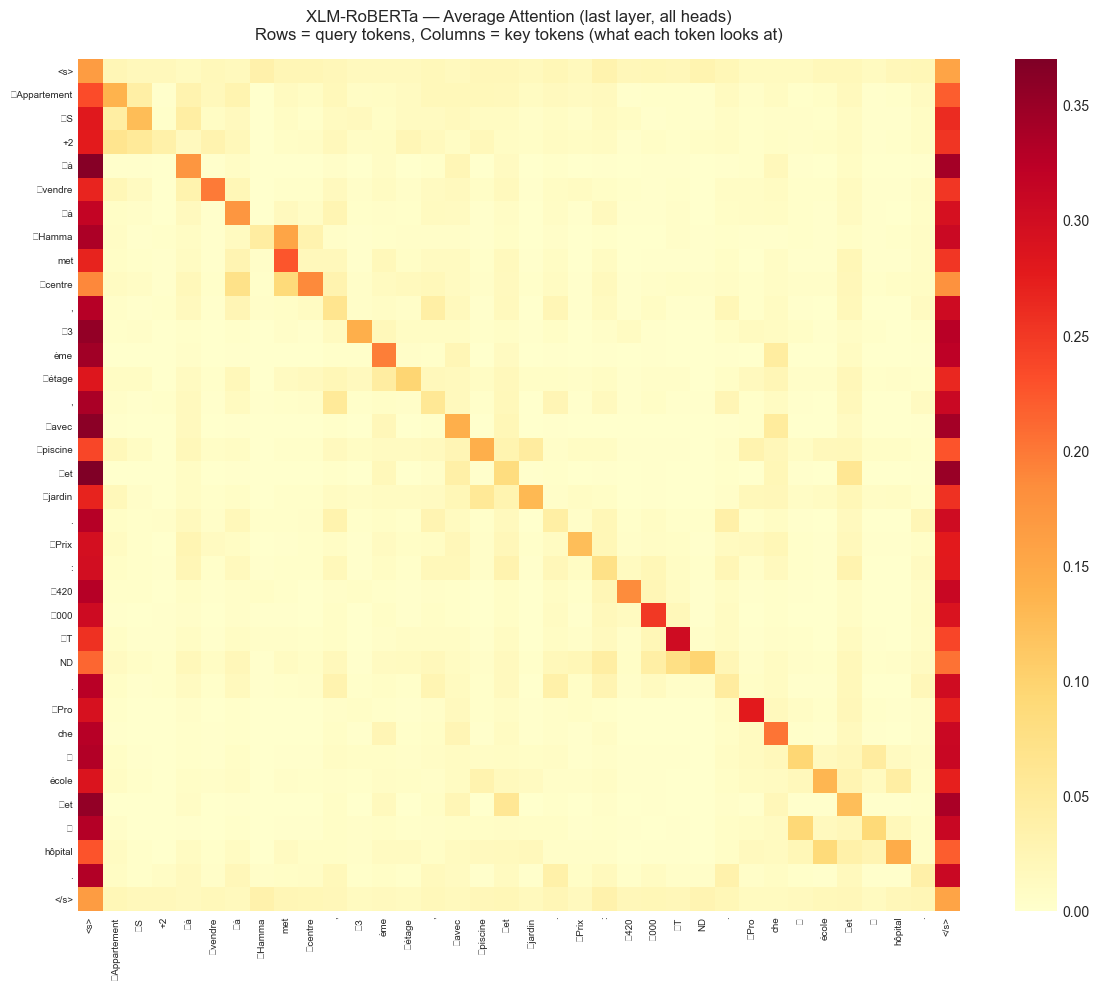

✅ Attention heatmap saved to attention_heatmap.png


In [31]:
# ── 5.2 Attention Visualization ────────────────────────────────────
# Show how the transformer model attends to relevant tokens in a description
# This illustrates WHY transformers understand multilingual, mixed-context text

try:
    import torch
    from transformers import AutoTokenizer, AutoModel

    print("Loading xlm-roberta-base for attention visualization...")
    attn_tokenizer = AutoTokenizer.from_pretrained('xlm-roberta-base')
    attn_model = AutoModel.from_pretrained('xlm-roberta-base', output_attentions=True)
    attn_model.eval()

    # Pick a sample description with clear price + location info
    sample = (
        "Appartement S+2 à vendre à Hammamet centre, 3ème étage, "
        "avec piscine et jardin. Prix: 420 000 TND. Proche école et hôpital."
    )

    tokens_input = attn_tokenizer(
        sample, return_tensors='pt', max_length=64,
        truncation=True, padding='max_length'
    )
    tokens_list = attn_tokenizer.convert_ids_to_tokens(tokens_input['input_ids'][0])
    # Remove padding tokens for display
    valid_len = (tokens_input['attention_mask'][0] == 1).sum().item()
    tokens_list = tokens_list[:valid_len]

    with torch.no_grad():
        outputs = attn_model(**tokens_input)

    # Average attention across all heads in the LAST layer
    last_layer_attn = outputs.attentions[-1][0]          # (heads, seq, seq)
    avg_attn = last_layer_attn.mean(dim=0).numpy()       # (seq, seq)
    avg_attn = avg_attn[:valid_len, :valid_len]           # trim padding

    # Plot
    fig, ax = plt.subplots(figsize=(12, 10))
    sns.heatmap(
        avg_attn, xticklabels=tokens_list, yticklabels=tokens_list,
        cmap='YlOrRd', ax=ax, linewidths=0, vmin=0
    )
    ax.set_title('XLM-RoBERTa — Average Attention (last layer, all heads)\n'
                 'Rows = query tokens, Columns = key tokens (what each token looks at)', pad=15)
    ax.set_xticklabels(tokens_list, rotation=90, fontsize=7)
    ax.set_yticklabels(tokens_list, rotation=0, fontsize=7)
    plt.tight_layout()
    plt.savefig('attention_heatmap.png', dpi=120)
    plt.show()
    print("✅ Attention heatmap saved to attention_heatmap.png")

except Exception as e:
    print(f"⚠️  Attention viz skipped: {e}")

In [32]:
# ── 5.3 Groq API — Prompt Engineering for structured extraction ─────
# Free signup: https://console.groq.com
# Model: llama-3.1-8b-instant — fast, multilingual, free tier

GROQ_AVAILABLE = False

if GROQ_API_KEY:
    try:
        from groq import Groq
        groq_client = Groq(api_key=GROQ_API_KEY)
        GROQ_AVAILABLE = True
        print("✅ Groq client initialized")
    except Exception as e:
        print(f"⚠️  Groq setup failed: {e}")
else:
    print("ℹ️  Groq skipped (no API key). Set GROQ_API_KEY in Section 1 config.")

# ── Prompt template (multilingual, structured output) ────
# We use a FEW-SHOT prompt with 2 examples — this is prompt engineering in action.
# Temperature=0.1 → near-deterministic JSON output (crucial for parsing)

EXTRACTION_PROMPT_TEMPLATE = """Tu es un expert en immobilier tunisien. Extrait les données structurées de cette annonce.
L'annonce peut être en français, arabe ou dialecte tunisien.
Réponds UNIQUEMENT avec un objet JSON valide, sans texte avant ou après.

Règles importantes:
- "MD" ou "MDT" en tunisien = mille dinars → multiplier par 1000 pour avoir en TND
  Exemple: "320 MD" = 320 000 TND
- S+1 = 2 pièces (salon + 1 chambre), S+2 = 3 pièces, S+3 = 4 pièces
- RDC = rez-de-chaussée = étage 0

Champs à extraire:
{
  "prix_tnd": <nombre entier en TND ou null>,
  "surface_m2": <nombre en m² ou null>,
  "pieces": <nombre entier de pièces ou null>,
  "etage": <numéro d'étage (0=RDC) ou null>,
  "ville": <ville ou quartier ou null>,
  "has_piscine": <0 ou 1>,
  "has_jardin": <0 ou 1>,
  "has_ascenseur": <0 ou 1>,
  "has_garage": <0 ou 1>,
  "has_terrasse": <0 ou 1>,
  "has_climatisation": <0 ou 1>,
  "bon_entourage_items": [<liste de strings parmi: "hôpital","école","pharmacie","marché","gare","bus","plage","centre-ville">]
}

Exemple 1:
Annonce: "S+2 au 3ème étage, 110m², prix 420 MD, piscine, ascenseur, proche école et hôpital à Hammamet"
Réponse: {"prix_tnd":420000,"surface_m2":110,"pieces":3,"etage":3,"ville":"Hammamet","has_piscine":1,"has_jardin":0,"has_ascenseur":1,"has_garage":0,"has_terrasse":0,"has_climatisation":0,"bon_entourage_items":["école","hôpital"]}

Exemple 2:
Annonce: "شقة للبيع في سوسة، 2 غرف، 85م²، بـ250 ألف دينار، تكييف، موقف سيارات"
Réponse: {"prix_tnd":250000,"surface_m2":85,"pieces":2,"etage":null,"ville":"Sousse","has_piscine":0,"has_jardin":0,"has_ascenseur":0,"has_garage":0,"has_terrasse":0,"has_climatisation":1,"bon_entourage_items":[]}

Annonce: {description}
Réponse:"""

print("✅ Prompt template defined (few-shot, multilingual, T=0.1)")

✅ Groq client initialized
✅ Prompt template defined (few-shot, multilingual, T=0.1)


In [33]:
# ── 5.4 Temperature demonstration ──────────────────────────────────
# Shows how temperature affects extraction consistency

if GROQ_AVAILABLE:
    test_desc = (
        "Appartement S+3 à Sousse, 4ème étage, 145m², "
        "terrasse vue mer, ascenseur, parking. Prix 680 MD. "
        "Proche plage (200m) et centre commercial."
    )

    print("=== Temperature experiment ===")
    print(f"Input: {test_desc}\n")

    for temp in [0.0, 0.1, 0.7]:
        try:
            resp = groq_client.chat.completions.create(
                model="llama-3.1-8b-instant",
                temperature=max(temp, 0.01),  # Groq min is 0.01
                max_tokens=300,
                messages=[{
                    "role": "user",
                    "content": EXTRACTION_PROMPT_TEMPLATE.replace('{description}', test_desc)
                }]
            )
            raw = resp.choices[0].message.content.strip()
            print(f"T={temp}: {raw[:200]}")
        except Exception as e:
            print(f"T={temp}: Error — {e}")
        time.sleep(1)  # rate limit
else:
    print("ℹ️  Groq not available — temperature demo skipped.")
    print("Note: For extraction tasks, use T=0.1 (deterministic).")
    print("      For creative/augmentation tasks, use T=0.7–1.0.")

=== Temperature experiment ===
Input: Appartement S+3 à Sousse, 4ème étage, 145m², terrasse vue mer, ascenseur, parking. Prix 680 MD. Proche plage (200m) et centre commercial.

T=0.0: {
  "prix_tnd": 680000,
  "surface_m2": 145,
  "pieces": 4,
  "etage": 4,
  "ville": "Sousse",
  "has_piscine": 0,
  "has_jardin": 0,
  "has_ascenseur": 1,
  "has_garage": 1,
  "has_terrasse": 1,
  "h
T=0.1: {
  "prix_tnd": 680000,
  "surface_m2": 145,
  "pieces": 4,
  "etage": 4,
  "ville": "Sousse",
  "has_piscine": 0,
  "has_jardin": 0,
  "has_ascenseur": 1,
  "has_garage": 1,
  "has_terrasse": 1,
  "h
T=0.7: {
  "prix_tnd": 680000,
  "surface_m2": 145,
  "pieces": 4,
  "etage": 4,
  "ville": "Sousse",
  "has_piscine": 0,
  "has_jardin": 0,
  "has_ascenseur": 1,
  "has_garage": 1,
  "has_terrasse": 1,
  "h


In [36]:
# ── 5.5 Batch LLM extraction ────────────────────────────────────────
# Run LLM only on rows where key fields (prix, surface, pieces) are STILL missing
# after regex extraction. This minimizes API calls.

def call_groq_extract(text, client, temperature=0.1, max_retries=2):
    """Call Groq and parse JSON response."""
    prompt = EXTRACTION_PROMPT_TEMPLATE.replace('{description}', str(text)[:1500])
    for attempt in range(max_retries):
        try:
            resp = client.chat.completions.create(
                model="llama-3.1-8b-instant",
                temperature=temperature,
                max_tokens=300,
                response_format={"type": "json_object"},
                messages=[{"role": "user", "content": prompt}]
            )
            raw = resp.choices[0].message.content.strip()
            parsed = json.loads(raw)
            if isinstance(parsed, list):
                parsed = parsed[0] if parsed and isinstance(parsed[0], dict) else {}
            return parsed
        except json.JSONDecodeError:
            m = re.search(r'\{.*\}', raw, re.DOTALL)
            if m:
                try:
                    parsed = json.loads(m.group(0))
                    if isinstance(parsed, list):
                        parsed = parsed[0] if parsed and isinstance(parsed[0], dict) else {}
                    return parsed
                except:
                    pass
        except Exception:
            time.sleep(2 ** attempt)
    return {}


def sanitize_llm_value(val):
    """Unwrap single-element lists; discard multi-element lists."""
    if isinstance(val, list):
        return val[0] if len(val) == 1 else None
    return val


LLM_FILL_COLUMNS = {
    'prix_tnd':          'prix',
    'surface_m2':        'surface',
    'pieces':            'pieces',
    'etage':             'etage',
    'ville':             'ville',
    'has_piscine':       'has_piscine',
    'has_jardin':        'has_jardin',
    'has_ascenseur':     'has_ascenseur',
    'has_garage':        'has_garage',
    'has_terrasse':      'has_terrasse',
    'has_climatisation': 'has_climatisation',
}

if GROQ_AVAILABLE:
    # Target rows: at least one key numeric field is still NaN
    needs_llm = (
        df['prix'].isna() | df['surface'].isna() | df['pieces'].isna()
    ) & df['description'].notna()

    candidates = df[needs_llm].index
    if LLM_SAMPLE_SIZE:
        candidates = candidates[:LLM_SAMPLE_SIZE]

    print(f"Running Groq LLM on {len(candidates):,} rows...")
    llm_results = {}  # idx → dict

    for i, idx in enumerate(tqdm(candidates)):
        result = call_groq_extract(df.at[idx, 'description'], groq_client)
        llm_results[idx] = result
        if (i + 1) % 10 == 0:
            time.sleep(2)

    # Sanitize: ensure every result is a dict
    llm_results = {
        idx: (res if isinstance(res, dict) else {})
        for idx, res in llm_results.items()
    }

    # Apply LLM results to df (only fill NaN cells)
    for llm_key, df_col in LLM_FILL_COLUMNS.items():
        count = 0
        for idx, result in llm_results.items():
            val = sanitize_llm_value(result.get(llm_key))
            if val is not None and pd.isna(df.at[idx, df_col]):
                df.at[idx, df_col] = val
                count += 1
        if count > 0:
            log(f"  LLM → {df_col}", count)

    # bon_entourage from LLM (store as list-string for later processing)
    df['bon_entourage_llm'] = pd.Series({
        idx: json.dumps(res.get('bon_entourage_items', []), ensure_ascii=False)
        for idx, res in llm_results.items()
    })

    print(f"\n✅ Groq extraction complete for {len(llm_results)} rows")

else:
    df['bon_entourage_llm'] = np.nan
    print("ℹ️  LLM batch skipped (no Groq key). Regex results will be used.")

Running Groq LLM on 500 rows...


100%|██████████| 500/500 [54:17<00:00,  6.51s/it]  


[CLEAN]   LLM → pieces → 2 rows affected
[CLEAN]   LLM → etage → 7 rows affected
[CLEAN]   LLM → ville → 2 rows affected
[CLEAN]   LLM → has_piscine → 21 rows affected
[CLEAN]   LLM → has_jardin → 21 rows affected
[CLEAN]   LLM → has_ascenseur → 19 rows affected
[CLEAN]   LLM → has_garage → 22 rows affected
[CLEAN]   LLM → has_terrasse → 21 rows affected
[CLEAN]   LLM → has_climatisation → 21 rows affected

✅ Groq extraction complete for 500 rows


                   raw_%  after_%  recovered
column                                      
prix                92.3     90.1      -7084
surface             61.9     66.1       6810
pieces              50.5     58.4      14809
etage                0.6     31.4      63233
ville               83.8     88.7       7885
gouvernerat         79.1     83.5       6962
has_piscine          4.0     19.0      30572
has_jardin           8.4     29.2      42357
has_ascenseur        3.9      6.8       5782
has_climatisation   16.1     26.9      21714
has_terrasse         7.5     26.8      39317
has_garage           3.3      9.0      11691


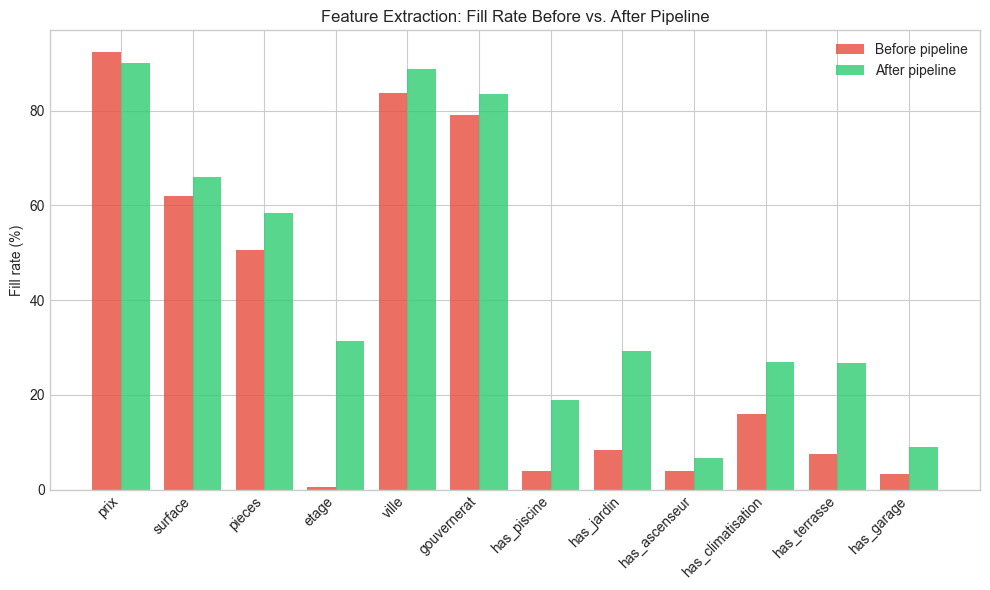

In [37]:
# ── 5.6 Extraction pipeline evaluation ─────────────────────────────
# Compare: how many rows now have each key field vs. raw data

KEY_FIELDS = ['prix', 'surface', 'pieces', 'etage', 'ville',
              'gouvernerat', 'has_piscine', 'has_jardin', 'has_ascenseur',
              'has_climatisation', 'has_terrasse', 'has_garage']

eval_data = []
for col in KEY_FIELDS:
    raw_fill = df_raw[col].notna().sum() if col in df_raw.columns else 0
    new_fill = df[col].notna().sum()
    total = len(df)
    eval_data.append({
        'column': col,
        'raw_%': raw_fill / len(df_raw) * 100,
        'after_%': new_fill / total * 100,
        'recovered': new_fill - raw_fill
    })

eval_df = pd.DataFrame(eval_data).set_index('column')
print(eval_df.round(1).to_string())

# Plot improvement
fig, ax = plt.subplots(figsize=(10, 6))
x = range(len(eval_df))
ax.bar(x, eval_df['raw_%'], width=0.4, label='Before pipeline', color='#e74c3c', alpha=0.8)
ax.bar([i + 0.4 for i in x], eval_df['after_%'], width=0.4, label='After pipeline', color='#2ecc71', alpha=0.8)
ax.set_xticks([i + 0.2 for i in x])
ax.set_xticklabels(eval_df.index, rotation=45, ha='right')
ax.set_ylabel('Fill rate (%)')
ax.set_title('Feature Extraction: Fill Rate Before vs. After Pipeline')
ax.legend()
plt.tight_layout()
plt.savefig('fill_rate_comparison.png', dpi=100)
plt.show()

---
## Section 6 — Geocoding (Free — OpenStreetMap / Nominatim)

**Nominatim** is the OpenStreetMap geocoder — completely free, no API key, no credit card.

**Rules to follow** (ToS):
- Max **1 request per second**
- Include a descriptive `user_agent`
- Do NOT mass-geocode millions of rows in production (use a local Nominatim instance)

Strategy: geocode only rows where lat/lng are missing, starting from most specific query.

In [39]:
# ── 6.1 Nominatim setup ────────────────────────────────────────────
from geopy.geocoders import Nominatim
from geopy.extra.rate_limiter import RateLimiter

geolocator = Nominatim(user_agent="tunisia_realestate_pipeline_v1", timeout=10)
# RateLimiter enforces 1 request/second + handles retries on errors
geocode = RateLimiter(geolocator.geocode, min_delay_seconds=1.1, max_retries=2, error_wait_seconds=5)

def build_geocode_query(row):
    """Build query string from most specific to least specific."""
    parts = []
    if pd.notna(row.get('adresse')) and len(str(row['adresse'])) > 5:
        parts.append(str(row['adresse'])[:80])   # cap length
    if pd.notna(row.get('ville')):
        parts.append(str(row['ville']))
    if pd.notna(row.get('gouvernerat')):
        parts.append(str(row['gouvernerat']))
    if pd.notna(row.get('code_postal')):
        parts.append(str(row['code_postal']))
    parts.append('Tunisie')
    return ', '.join(parts)

def safe_geocode(query):
    """Geocode and return (lat, lng) or (nan, nan)."""
    if not query or len(query) < 5:
        return np.nan, np.nan
    try:
        location = geocode(query, country_codes='tn')
        if location:
            return location.latitude, location.longitude
    except Exception:
        pass
    return np.nan, np.nan

print("✅ Geocoder ready")

# Quick test
lat, lng = safe_geocode("Hammamet, Nabeul, Tunisie")
print(f"Test: Hammamet → lat={lat:.4f}, lng={lng:.4f}")

✅ Geocoder ready
Test: Hammamet → lat=36.4013, lng=10.5573


In [40]:
# ── 6.2 Batch geocoding ────────────────────────────────────────────
needs_geo = df['latitude'].isna() | df['longitude'].isna()
geo_candidates = df[needs_geo].index

if GEO_SAMPLE_SIZE:
    geo_candidates = geo_candidates[:GEO_SAMPLE_SIZE]

print(f"Geocoding {len(geo_candidates):,} rows (1 req/sec → ~{len(geo_candidates)//60} minutes)...")

geocoded_lats, geocoded_lngs = {}, {}
# Cache queries to avoid re-geocoding same city
query_cache = {}

for idx in tqdm(geo_candidates):
    row = df.loc[idx]
    query = build_geocode_query(row)

    if query in query_cache:
        lat, lng = query_cache[query]
    else:
        lat, lng = safe_geocode(query)
        query_cache[query] = (lat, lng)

    if not np.isnan(lat):
        geocoded_lats[idx] = lat
        geocoded_lngs[idx] = lng

# Apply
for idx, lat in geocoded_lats.items():
    df.at[idx, 'latitude']  = lat
    df.at[idx, 'longitude'] = geocoded_lngs[idx]

log("geocoding: lat/lng filled", len(geocoded_lats))
print(f"\nlat missing after: {df['latitude'].isna().sum():,} ({df['latitude'].isna().mean()*100:.1f}%)")

Geocoding 2,000 rows (1 req/sec → ~33 minutes)...


100%|██████████| 2000/2000 [05:36<00:00,  5.94it/s]

[CLEAN] geocoding: lat/lng filled → 1,613 rows affected

lat missing after: 191,569 (93.6%)


In [41]:
# ── 6.3 Gouvernerat centroid fallback ─────────────────────────────
# For rows still missing lat/lng: use the centroid coordinates
# of the gouvernerat (pre-computed from OSM data)

GOUV_CENTROIDS = {
    'Tunis':       (36.8065, 10.1815), 'Ariana':      (36.8625, 10.1956),
    'Ben Arous':   (36.7530, 10.2280), 'Manouba':     (36.8095, 10.0980),
    'Nabeul':      (36.4561, 10.7376), 'Zaghouan':    (36.4029, 10.1432),
    'Bizerte':     (37.2744, 9.8739),  'Béja':        (36.7256, 9.1817),
    'Jendouba':    (36.5011, 8.7803),  'Le Kef':      (36.1826, 8.7149),
    'Siliana':     (36.0844, 9.3708),  'Sousse':      (35.8245, 10.6346),
    'Monastir':    (35.7643, 10.8113), 'Mahdia':      (35.5047, 11.0622),
    'Sfax':        (34.7400, 10.7600), 'Kairouan':    (35.6781, 10.0964),
    'Kasserine':   (35.1727, 8.8304),  'Sidi Bouzid': (35.0382, 9.4849),
    'Gabès':       (33.8881, 10.0975), 'Médenine':    (33.3549, 10.5055),
    'Tataouine':   (32.9211, 10.4510), 'Gafsa':       (34.4249, 8.7842),
    'Tozeur':      (33.9197, 8.1335),  'Kébili':      (33.7053, 8.9710),
}

still_no_geo = df['latitude'].isna() & df['gouvernerat'].notna()
df.loc[still_no_geo, 'latitude']  = df.loc[still_no_geo, 'gouvernerat'].map(
    lambda g: GOUV_CENTROIDS.get(g, (np.nan, np.nan))[0]
)
df.loc[still_no_geo, 'longitude'] = df.loc[still_no_geo, 'gouvernerat'].map(
    lambda g: GOUV_CENTROIDS.get(g, (np.nan, np.nan))[1]
)
log("lat/lng: gouvernerat centroid fallback", still_no_geo.sum())

# Mark centroid rows so models know precision level
df['geo_precision'] = 'exact'
df.loc[still_no_geo, 'geo_precision'] = 'gouvernerat_centroid'
df.loc[df['latitude'].isna(), 'geo_precision'] = 'missing'

print(df['geo_precision'].value_counts())

[CLEAN] lat/lng: gouvernerat centroid fallback → 157,984 rows affected
geo_precision
gouvernerat_centroid    157984
missing                  33585
exact                    13176
Name: count, dtype: int64


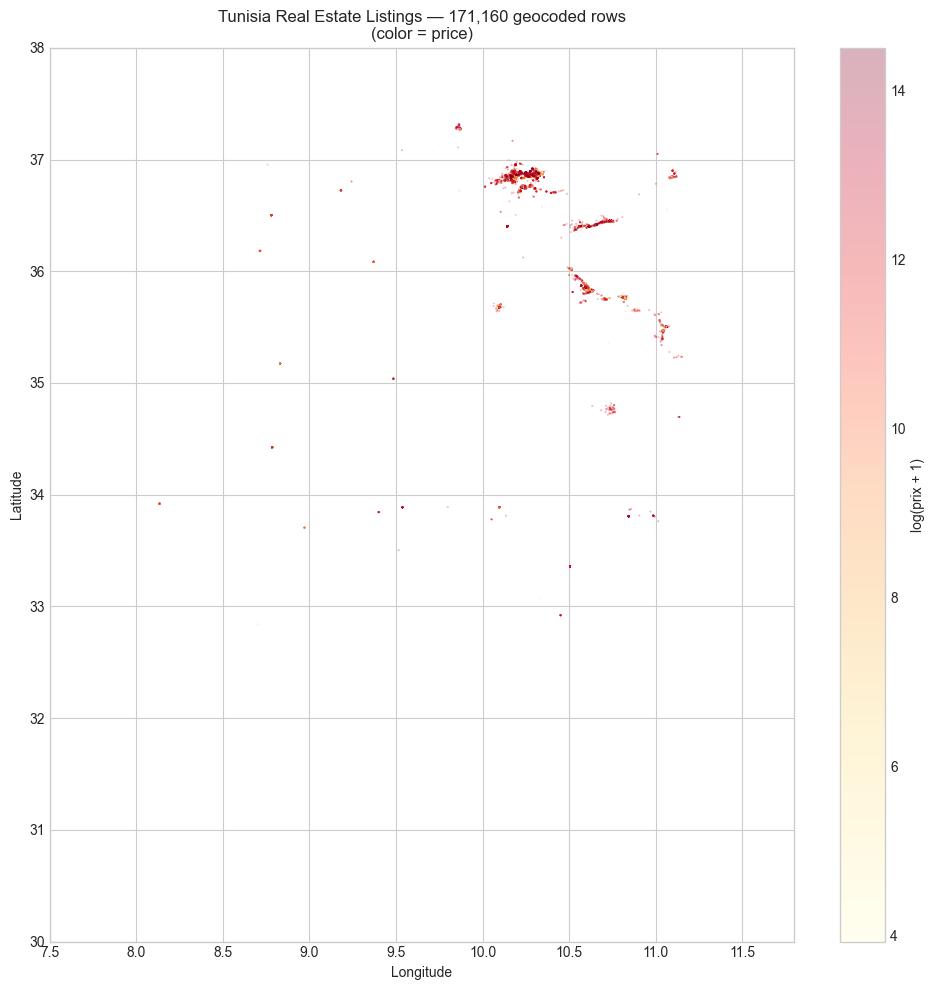

In [42]:
# ── 6.4 Plot geocoded listings on Tunisia map ──────────────────────
geo_df = df.dropna(subset=['latitude', 'longitude'])

fig, ax = plt.subplots(figsize=(10, 10))
scatter = ax.scatter(
    geo_df['longitude'], geo_df['latitude'],
    c=np.log1p(geo_df['prix'].clip(upper=2e6)),
    cmap='YlOrRd', alpha=0.3, s=2, linewidths=0
)
plt.colorbar(scatter, ax=ax, label='log(prix + 1)')
ax.set_xlim(7.5, 11.8)
ax.set_ylim(30.0, 38.0)
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title(f'Tunisia Real Estate Listings — {len(geo_df):,} geocoded rows\n(color = price)')
plt.tight_layout()
plt.savefig('listings_map.png', dpi=120)
plt.show()

---
## Section 7 — Proximity Score → `bon_entourage`

A **composite proximity score** that captures how well-served the listing's location is.  
Sources (in priority order):
1. Existing scraped columns (hopital, ecole, pharmacie, …)
2. Description keyword extraction (Section 4)
3. LLM extraction (Section 5, if Groq available)

Final score: **0–6** (1 point per facility type found nearby)

In [43]:
# ── 7.1 Extract bon_entourage keywords from description ────────────
BON_ENTOURAGE_KEYWORDS = {
    'hôpital':      r'hôpital|hopital|clinique|polyclinique|chu\b|centre\s*hospitalier|مستشفى|عيادة',
    'école':        r'école|ecole|lycée|université|collège|maternelle|مدرسة|ثانوية|جامعة|مدرسة',
    'pharmacie':    r'pharmacie|صيدلية',
    'marché':       r'marché|supermarché|supermarche|hypermarché|centre\s*commercial|carrefour|géant|سوق|ماركت',
    'transport':    r'\bgare\b|\bstation\b|métro|tramway|\btrain\b|\bbus\b|محطة|مترو|قطار|حافلة|transport',
    'plage':        r'\bplage\b|bord\s*de\s*mer|front\s*de\s*mer|vue\s*mer|شاطئ|\bبحر\b',
    'centre-ville': r'centre.ville|centre\s*ville|downtown|وسط\s*(?:البلاد|المدينة)',
}

def extract_entourage_from_text(text):
    """Return set of facility types found in text."""
    if pd.isna(text):
        return set()
    text_str = str(text).lower()
    found = set()
    for label, pattern in BON_ENTOURAGE_KEYWORDS.items():
        if re.search(pattern, text_str, re.IGNORECASE):
            found.add(label)
    return found

print("Extracting bon_entourage keywords from descriptions...")
entourage_from_desc = df['description'].progress_apply(extract_entourage_from_text)
print("✅ Done")

# Sample
for i, s in entourage_from_desc.items():
    if len(s) >= 2:
        print(f"  row {i}: {s}")
        break

Extracting bon_entourage keywords from descriptions...


100%|██████████| 204745/204745 [01:00<00:00, 3405.70it/s]

✅ Done
  row 0: {'centre-ville', 'plage'}


Computing bon_entourage scores...


100%|██████████| 204745/204745 [00:20<00:00, 9945.67it/s] 



bon_entourage distribution:
bon_entourage
0    158287
1     38681
2      6282
3      1236
4       215
5        40
6         3
7         1
Name: count, dtype: int64


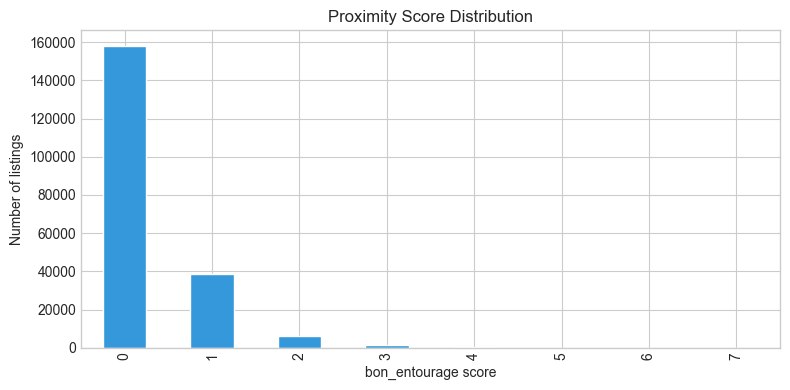

In [44]:
# ── 7.2 Compute bon_entourage score ────────────────────────────────
# Combine: scraped binary columns + description keywords + LLM results

SCRAPED_TO_ENTOURAGE = {
    'hopital':   'hôpital',
    'ecole':     'école',
    'pharmacie': 'pharmacie',
    'magasin':   'marché',
    'marche':    'marché',
    'railway':   'transport',
    'bus':       'transport',
    'restaurant': 'marché',  # commercial activity → counts as marché
}

def compute_bon_entourage(row, desc_facilities):
    """Compute bon_entourage score for one row."""
    facilities = set(desc_facilities)  # from description keywords

    # Add from scraped columns
    for col, label in SCRAPED_TO_ENTOURAGE.items():
        if row.get(col) == 1:
            facilities.add(label)

    # Add from LLM (if available)
    llm_items = row.get('bon_entourage_llm')
    if pd.notna(llm_items):
        try:
            for item in json.loads(llm_items):
                facilities.add(item)
        except Exception:
            pass

    return len(facilities)

print("Computing bon_entourage scores...")
df['bon_entourage'] = [
    compute_bon_entourage(df.iloc[i], entourage_from_desc.iloc[i])
    for i in tqdm(range(len(df)))
]

print("\nbon_entourage distribution:")
print(df['bon_entourage'].value_counts().sort_index())

fig, ax = plt.subplots(figsize=(8, 4))
df['bon_entourage'].value_counts().sort_index().plot(kind='bar', ax=ax, color='#3498db', edgecolor='white')
ax.set_xlabel('bon_entourage score')
ax.set_ylabel('Number of listings')
ax.set_title('Proximity Score Distribution')
plt.tight_layout()
plt.savefig('bon_entourage_dist.png', dpi=100)
plt.show()

---
## Section 8 — Premium Feature → `haut_standing`

Binary flag: **1** if the property qualifies as high-end / luxury based on amenities + standing label.

| Criterion | Points |
|---|---|
| `has_piscine = 1` (pool) | +3 |
| `standing = 'Haut Standing'` | +3 |
| `has_jardin = 1` (garden) | +1 |
| `has_terrasse = 1` (terrace) | +1 |
| `has_ascenseur = 1` (elevator) | +1 |
| `has_climatisation = 1` (A/C) | +1 |
| `has_gardien = 1` (concierge) | +1 |
| price in top 25% for contrat type | +2 |

**`haut_standing = 1` if total score ≥ 3**

In [45]:
# ── 8.1 Compute price quantile thresholds per contrat type ─────────
price_q75 = df.groupby('contrat')['prix'].quantile(0.75)
print("Price 75th percentile by contrat type:")
print(price_q75)

def get_prix_q75(row):
    return price_q75.get(row['contrat'], np.nan)

df['prix_q75_contrat'] = df.apply(get_prix_q75, axis=1)

# ── 8.2 Compute haut_standing score ───────────────────────────────
def compute_haut_standing(row):
    score = 0

    if row.get('has_piscine')    == 1: score += 3
    if str(row.get('standing', '')).lower() == 'haut standing': score += 3
    if row.get('has_jardin')     == 1: score += 1
    if row.get('has_terrasse')   == 1: score += 1
    if row.get('has_ascenseur')  == 1: score += 1
    if row.get('has_climatisation') == 1: score += 1
    if row.get('has_gardien')    == 1: score += 1

    # Price in top 25%
    if pd.notna(row.get('prix')) and pd.notna(row.get('prix_q75_contrat')):
        if row['prix'] >= row['prix_q75_contrat']:
            score += 2

    return int(score >= 3)

print("\nComputing haut_standing...")
df['haut_standing'] = df.apply(compute_haut_standing, axis=1)

print(f"\nhaut_standing distribution:")
print(df['haut_standing'].value_counts())
print(f"  → {df['haut_standing'].mean()*100:.1f}% of listings classified as haut standing")

# Cross-check with existing standing column
cross = pd.crosstab(df['standing'].fillna('Unknown'), df['haut_standing'])
print("\nCross-check with original standing column:")
print(cross)

Price 75th percentile by contrat type:
contrat
autre                417000.0
colocation              300.0
location               2200.0
location_vacances      1000.0
vente                750000.0
Name: prix, dtype: float64

Computing haut_standing...

haut_standing distribution:
haut_standing
0    145415
1     59330
Name: count, dtype: int64
  → 29.0% of listings classified as haut standing

Cross-check with original standing column:
haut_standing        0      1
standing                     
Ancien             113     38
Haut Standing        0    674
Moyen Standing     502    150
Populaire           63      7
Unknown         144737  58461


---
## Section 9 — Final Cleaning & Export

In [46]:
# ── 9.1 Final type coercion ────────────────────────────────────────
# Ensure correct dtypes before export

# Numeric → float
for col in ['prix', 'surface', 'pieces', 'etage', 'annee_constr', 'latitude', 'longitude']:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# pieces and etage should be integers where possible
# (keep as float to preserve NaN)

# Boolean columns → int (0/1/NaN)
for col in BOOL_COLS + ['haut_standing']:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce').map(
            lambda x: int(x) if pd.notna(x) and x in (0, 1) else np.nan
        )

# bon_entourage → int
df['bon_entourage'] = df['bon_entourage'].fillna(0).astype(int)

print("✅ Final dtypes:")
print(df.dtypes)

✅ Final dtypes:
adresse               object
annee_constr         float64
bus                  float64
caracteristiques      object
code_postal           object
                      ...   
bon_entourage_llm     object
geo_precision         object
bon_entourage          int64
prix_q75_contrat     float64
haut_standing          int64
Length: 62, dtype: object


In [47]:
# ── 9.2 Drop columns with very high missingness that add no value ──
# We drop: code_postal (99.9% missing), date_scraping (100% missing),
#   ecole_nearest, hopital_nearest, etc. (99%+ missing, replaced by bon_entourage)
# We KEEP: the original proximity binary columns (some were filled)

COLS_TO_DROP = [
    'date_scraping',      # 100% null
    'code_postal',        # 99.9% null (extracted to code_postal_carac if present)
    'ecole_nearest',      # distance info mostly null
    'hopital_nearest',
    'pharmacie_nearest',
    'magasin_nearest',
    'marche_nearest',
    'restaurant_nearest',
    'prix_q75_contrat',   # intermediate computation column
    'bon_entourage_llm',  # intermediate
    'prix_original',      # keep cleaned version only
    'surface_original',
    'pieces_original',
    'etage_original',
]
# Only drop if they exist
COLS_TO_DROP = [c for c in COLS_TO_DROP if c in df.columns]

df_final = df.drop(columns=COLS_TO_DROP)
print(f"Shape after column drop: {df_final.shape}")
print(f"Columns kept: {df_final.columns.tolist()}")

Shape after column drop: (204745, 48)
Columns kept: ['adresse', 'annee_constr', 'bus', 'caracteristiques', 'contrat', 'date_publication', 'description', 'ecole', 'etage', 'gouvernerat', 'has_ascenseur', 'has_balcon', 'has_chaffage', 'has_climatisation', 'has_garage', 'has_gardien', 'has_jardin', 'has_parking', 'has_piscine', 'has_terrasse', 'hopital', 'images', 'latitude', 'longitude', 'magasin', 'marche', 'pharmacie', 'pieces', 'prix', 'railway', 'restaurant', 'source', 'standing', 'surface', 'titre', 'type', 'url', 'ville', 'pub_year', 'pub_month', 'desc_clean', 'carac_block', 'contrat_carac', 'surface_carac', 'code_postal_carac', 'geo_precision', 'bon_entourage', 'haut_standing']


In [48]:
# ── 9.3 Final pipeline summary ─────────────────────────────────────
print("="*60)
print("PIPELINE SUMMARY")
print("="*60)
print(f"  Original rows:   {len(df_raw):>10,}")
print(f"  After dedup:     {len(df_final):>10,}  ({(1-len(df_final)/len(df_raw))*100:.1f}% removed)")
print(f"  Columns:         {len(df_final.columns):>10}")
print()
print("Key features fill rate:")
for col in ['prix', 'surface', 'pieces', 'etage', 'ville', 'gouvernerat',
            'latitude', 'longitude', 'has_piscine', 'has_jardin',
            'has_climatisation', 'bon_entourage', 'haut_standing']:
    if col in df_final.columns:
        rate = df_final[col].notna().mean() * 100
        print(f"  {col:25s}: {rate:5.1f}%")

print()
print("Cleaning actions:")
for entry in cleaning_log:
    print(" ", entry)

print()
print("New columns added:")
new_cols = set(df_final.columns) - set(df_raw.columns)
for c in sorted(new_cols):
    print(f"  + {c}")

PIPELINE SUMMARY
  Original rows:      207,374
  After dedup:        204,745  (1.3% removed)
  Columns:                 48

Key features fill rate:
  prix                     :  90.1%
  surface                  :  66.1%
  pieces                   :  58.4%
  etage                    :  31.4%
  ville                    :  88.7%
  gouvernerat              :  83.5%
  latitude                 :  83.6%
  longitude                :  83.6%
  has_piscine              :  19.0%
  has_jardin               :  29.2%
  has_climatisation        :  26.9%
  bon_entourage            : 100.0%
  haut_standing            : 100.0%

Cleaning actions:
  [CLEAN] type normalization → 681 rows affected
  [CLEAN] contrat normalization
  [CLEAN] gouvernerat/ville normalization
  [CLEAN] prix: outliers zeroed → 9,563 rows affected
  [CLEAN] surface: outliers (< 5 or > 10K/50K m²) → NaN → 715 rows affected
  [CLEAN] pieces: outliers (< 0 or > 20) → NaN → 98 rows affected
  [CLEAN] etage: outliers → NaN → 3 rows affec

In [49]:
# ── 9.4 Export ─────────────────────────────────────────────────────
df_final.to_csv(OUTPUT_PATH, index=False, encoding='utf-8-sig')  # utf-8-sig for Arabic in Excel
print(f"✅ Saved to: {OUTPUT_PATH.resolve()}")
print(f"   Rows: {len(df_final):,}  |  Columns: {len(df_final.columns)}  |  Size: {OUTPUT_PATH.stat().st_size / 1e6:.1f} MB")

# Preview
print("\nSample cleaned row:")
sample_row = df_final.dropna(subset=['prix', 'surface', 'ville']).iloc[0]
for col, val in sample_row.items():
    if col not in ['description', 'desc_clean', 'carac_block', 'caracteristiques', 'images', 'url']:
        print(f"  {col:25s}: {val}")

✅ Saved to: C:\Users\21650\Desktop\Pi\tunisia_realestate_cleaned.csv
   Rows: 204,745  |  Columns: 48  |  Size: 435.6 MB

Sample cleaned row:
  adresse                  : nan
  annee_constr             : nan
  bus                      : nan
  contrat                  : vente
  date_publication         : NaT
  ecole                    : nan
  etage                    : 2.0
  gouvernerat              : Nabeul
  has_ascenseur            : nan
  has_balcon               : nan
  has_chaffage             : 1.0
  has_climatisation        : 1.0
  has_garage               : nan
  has_gardien              : nan
  has_jardin               : nan
  has_parking              : nan
  has_piscine              : nan
  has_terrasse             : 1.0
  hopital                  : nan
  latitude                 : 36.4512897
  longitude                : 10.7355915
  magasin                  : nan
  marche                   : nan
  pharmacie                : nan
  pieces                   : 2.0
  prix        

---
## Appendix — Fine-tuning Notes

### How to fine-tune a model for better extraction (free, using Hugging Face)

If you want to improve extraction accuracy beyond prompt engineering:

**1. Create labeled dataset** (100–500 examples manually annotated):
```json
{"text": "S+2 au 3ème, 110m², prix 420 MD, piscine...",
 "prix_tnd": 420000, "surface_m2": 110, "pieces": 3, "has_piscine": 1}
```

**2. Fine-tune with LoRA** (Parameter-Efficient Fine-Tuning, uses very little GPU memory):
```python
from peft import LoraConfig, get_peft_model
from transformers import AutoModelForCausalLM, TrainingArguments, Trainer

# Use a small multilingual model
base_model = AutoModelForCausalLM.from_pretrained("mistralai/Mistral-7B-Instruct-v0.3")
lora_config = LoraConfig(r=8, lora_alpha=16, target_modules=["q_proj", "v_proj"])
model = get_peft_model(base_model, lora_config)
# Then train with your labeled examples
```

**3. Free GPU options**:
- Google Colab (free T4 GPU)
- Kaggle Notebooks (free P100 GPU, 30h/week)
- Hugging Face Spaces (for inference)

**4. Evaluation metrics** for this extraction task:
- **Numeric fields** (prix, surface): MAE, relative error %
- **Categorical** (ville, type): Accuracy, F1
- **Binary** (has_piscine etc.): Precision, Recall, F1
- **End-to-end**: downstream price prediction R² improvement